#1. Build a decision Tree Classifier from scratch in Python, Choose the features based on Information Gain

---



In [22]:
import numpy as np
from collections import Counter

class DecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def entropy(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        return -np.sum([p * np.log2(p) for p in probs if p > 0])

    def information_gain(self, X_column, y, threshold):
        parent_entropy = self.entropy(y)

        left_idxs = X_column <= threshold
        right_idxs = X_column > threshold

        if len(y[left_idxs]) == 0 or len(y[right_idxs]) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(y[left_idxs]), len(y[right_idxs])

        e_l = self.entropy(y[left_idxs])
        e_r = self.entropy(y[right_idxs])

        child_entropy = (n_l/n)*e_l + (n_r/n)*e_r
        return parent_entropy - child_entropy

    def best_split(self, X, y):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feature_idx in range(X.shape[1]):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for t in thresholds:
                gain = self.information_gain(X_column, y, t)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feature_idx
                    split_thresh = t

        return split_idx, split_thresh

    def build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if (depth >= self.max_depth or num_labels == 1):
            return Counter(y).most_common(1)[0][0]

        feat_idx, threshold = self.best_split(X, y)

        if feat_idx is None:
            return Counter(y).most_common(1)[0][0]

        left_idxs = X[:, feat_idx] <= threshold
        right_idxs = X[:, feat_idx] > threshold

        left = self.build_tree(X[left_idxs], y[left_idxs], depth+1)
        right = self.build_tree(X[right_idxs], y[right_idxs], depth+1)

        return {"feature": feat_idx, "threshold": threshold, "left": left, "right": right}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["threshold"]:
            return self.predict_sample(x, tree["left"])
        else:
            return self.predict_sample(x, tree["right"])

    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])

🔹 1. Entropy is working correctly

In [23]:
tree = DecisionTree()
y = np.array([0, 0, 1, 1])
print(tree.entropy(y))

1.0


🔹 2. Information Gain is correct

In [24]:
X_column = np.array([1, 2, 3, 4])
y = np.array([0, 0, 1, 1])

print(tree.information_gain(X_column, y, 2))

1.0


# 2. Plot self entropy and Gini’s Impurity against the bias in case of coin tossing **experiment**

🔹 Formula

Entropy:
H(p) = -p * log2(p) - (1 - p) * log2(1 - p)

Gini Impurity:
G(p) = 1 - (p^2 + (1 - p)^2)

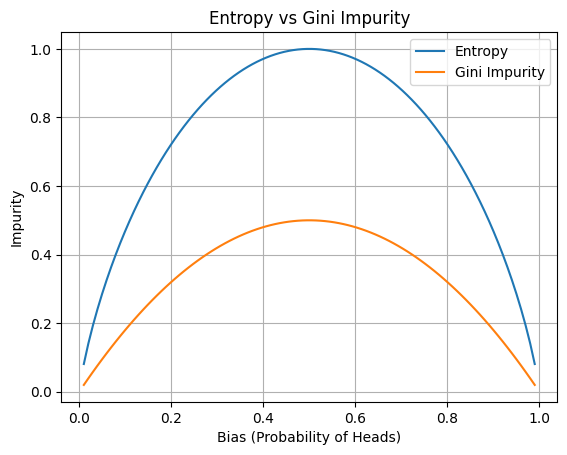

In [25]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.01, 0.99, 100)

entropy = -p*np.log2(p) - (1-p)*np.log2(1-p)
gini = 1 - (p**2 + (1-p)**2)

plt.plot(p, entropy, label="Entropy")
plt.plot(p, gini, label="Gini Impurity")

plt.xlabel("Bias (Probability of Heads)")
plt.ylabel("Impurity")
plt.title("Entropy vs Gini Impurity")
plt.legend()
plt.grid()

plt.show()

🔹 Observation

- Both Entropy and Gini Impurity are maximum at p = 0.5
- Entropy curve is sharper → more sensitive to changes in probability
- Gini Impurity is computationally simpler and faster → widely used in practice

# 3. Try to use Decision Tree Classifier to find out if the person will get high, medium or low salary based on the rest of the features. The data is shared on moodle. Visualize the same using graphViz

🔹 Step 1: Convert Salary → Classes (Low / Medium / High)

In [26]:
import pandas as pd

df = pd.read_csv("salary_data.csv")

def categorize_salary(salary):
    if salary < 60000:
        return "Low"
    elif salary < 100000:
        return "Medium"
    else:
        return "High"

df["Salary_Class"] = df["Monthly_Salary"].apply(categorize_salary)

🔹 Step 2: Drop Irrelevant Columns

In [27]:
df = df.drop(["EmployeeID", "Name", "Monthly_Salary"], axis=1)

🔹 Step 3: Encode Categorical Features

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

🔹 Step 4: Split Features & Target

In [29]:
X = df.drop("Salary_Class", axis=1)
y = df["Salary_Class"]

🔹 Step 5: Train Decision Tree (Information Gain)

In [30]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4
)

model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

🔹 Step 6: Visualize using Graphviz

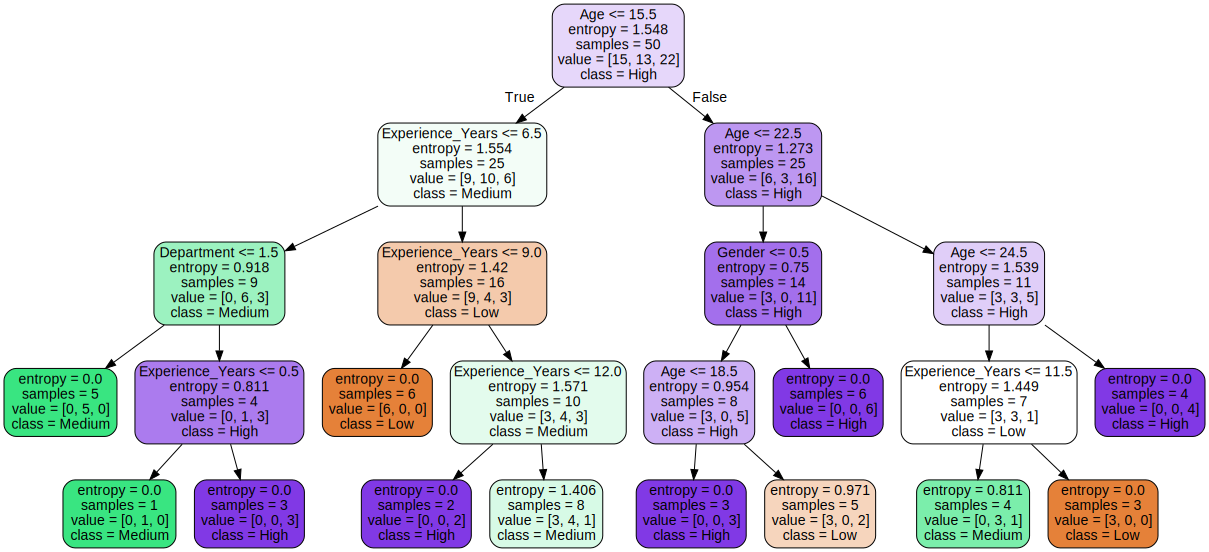

In [31]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)

graph